In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [2]:
zip_path = "BCICIV_4_mat.zip"
extract_path = "BCICIV_4_data"

print("Zip path:", zip_path)
print("Extract folder:", extract_path)

Zip path: BCICIV_4_mat.zip
Extract folder: BCICIV_4_data


In [3]:
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [4]:
for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    for file in files:
        print("  ", file)

Folder: BCICIV_4_data
   sub1_comp.mat
   sub2_comp.mat
   sub3_comp.mat


In [5]:
file_path = os.path.join(extract_path, "sub2_comp.mat")
data = loadmat(file_path)

print("Loaded file:", file_path)

Loaded file: BCICIV_4_data\sub2_comp.mat


In [6]:
print("Keys in the .mat file:")
print(data.keys())

Keys in the .mat file:
dict_keys(['__header__', '__version__', '__globals__', 'train_data', 'test_data', 'train_dg'])


In [7]:
train_data = data["train_data"]
train_dg = data["train_dg"]
test_data = data["test_data"]

print("train_data shape:", train_data.shape)
print("train_dg shape:", train_dg.shape)
print("test_data shape:", test_data.shape)

train_data shape: (400000, 48)
train_dg shape: (400000, 5)
test_data shape: (200000, 48)


In [8]:
n_samples, n_channels = train_data.shape
n_targets = train_dg.shape[1]

print(f"Number of training samples: {n_samples}")
print(f"Number of neural channels: {n_channels}")
print(f"Number of target outputs (fingers): {n_targets}")

Number of training samples: 400000
Number of neural channels: 48
Number of target outputs (fingers): 5


In [9]:
print("First 5 rows of train_data:")
print(train_data[:5])

print("\nFirst 5 rows of train_dg:")
print(train_dg[:5])

First 5 rows of train_data:
[[  -872    164    609  -4169  -3011  -1713  -1561   -616   -700   3692
   -1077    -48   1891   -753   1489   1141     -8     76    574     93
    2126   1251  -1367   1074   3095   -843   8970  -5569   3564   2428
     494 -11532  -1352   -393   -450  -1551  -1312   -342    961  -1881
   -2825   -113   -495     76   2439  -2776  -7720    -96]
 [ -1191    -78    454  -4212  -3018  -1808  -1778   -597   -682   3733
   -1199    -33   1843   -767   1402   1001    -68   -103    457     -1
    1359   1071  -1525    906   3147   -817   8980  -5533   3447   2302
     436 -11469  -1434   -533   -444  -1626  -1368   -387    916  -2019
   -2935   -249   -700     -9   2380  -2787  -7544   -188]
 [ -1507   -395    204  -4429  -3134  -2046  -2065   -630   -826   3654
   -1394   -153   1690   -872   1196    735   -207   -243    267   -219
     577    782  -1724    737   3134   -862   8840  -5638   3231   2069
     277 -11500  -1647   -778   -485  -1819  -1443   -429    7

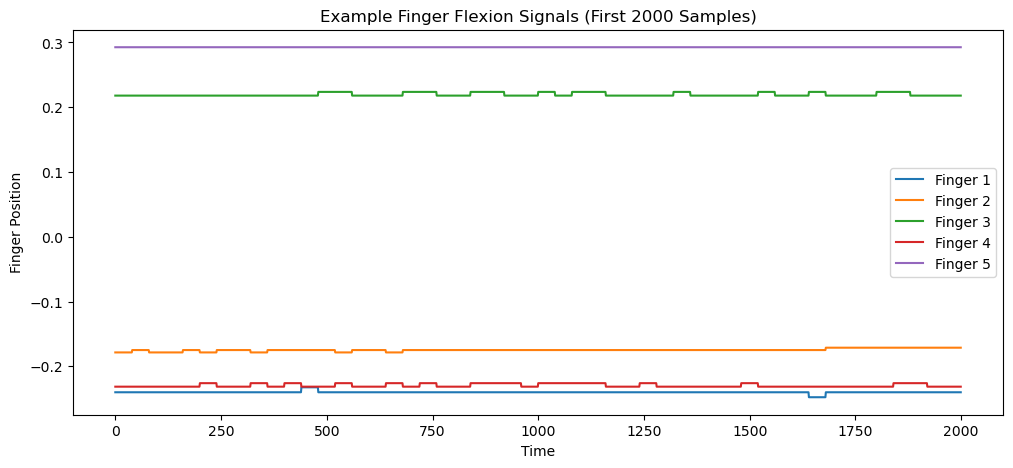

In [10]:
plt.figure(figsize=(12, 5))
for i in range(train_dg.shape[1]):
    plt.plot(train_dg[:2000, i], label=f'Finger {i+1}')
plt.title("Example Finger Flexion Signals (First 2000 Samples)")
plt.xlabel("Time")
plt.ylabel("Finger Position")
plt.legend()
plt.show()

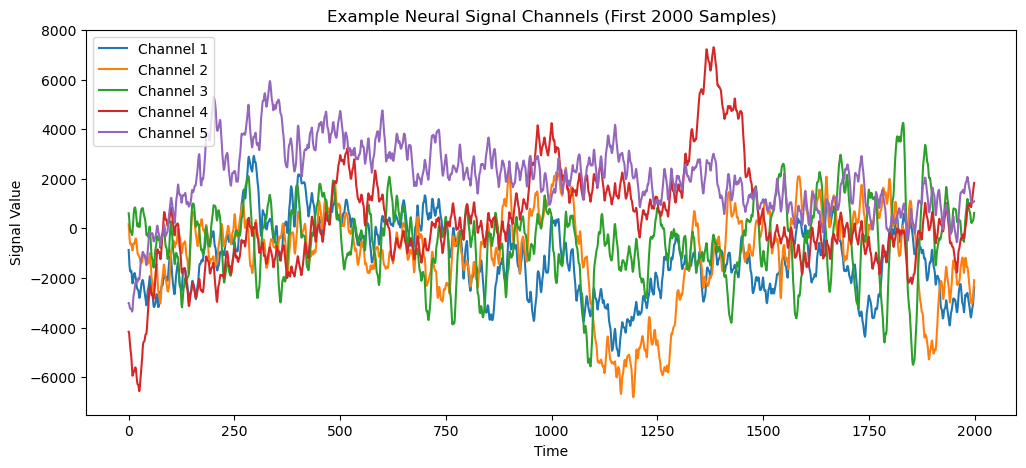

In [11]:
plt.figure(figsize=(12, 5))
for i in range(min(5, train_data.shape[1])):
    plt.plot(train_data[:2000, i], label=f'Channel {i+1}')
plt.title("Example Neural Signal Channels (First 2000 Samples)")
plt.xlabel("Time")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

In [12]:
print("Missing values in train_data:", np.isnan(train_data).sum())
print("Missing values in train_dg:", np.isnan(train_dg).sum())
print("Missing values in test_data:", np.isnan(test_data).sum())

Missing values in train_data: 0
Missing values in train_dg: 0
Missing values in test_data: 0


In [13]:
X = train_data
y = train_dg

print("Input X shape:", X.shape)
print("Target y shape:", y.shape)

Input X shape: (400000, 48)
Target y shape: (400000, 5)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (320000, 48)
X_val: (80000, 48)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Scaling complete.")

Scaling complete.


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

baseline_model = MultiOutputRegressor(LinearRegression())
baseline_model.fit(X_train_scaled, y_train)

print("Wiener Filter (Linear Regression) trained.")

Wiener Filter (Linear Regression) trained.


In [17]:
from sklearn.metrics import r2_score

y_pred_baseline = baseline_model.predict(X_val_scaled)

baseline_r2 = r2_score(y_val, y_pred_baseline, multioutput='uniform_average')

print("Baseline Wiener Filter R² score:", baseline_r2)

Baseline Wiener Filter R² score: 0.03842790195638783


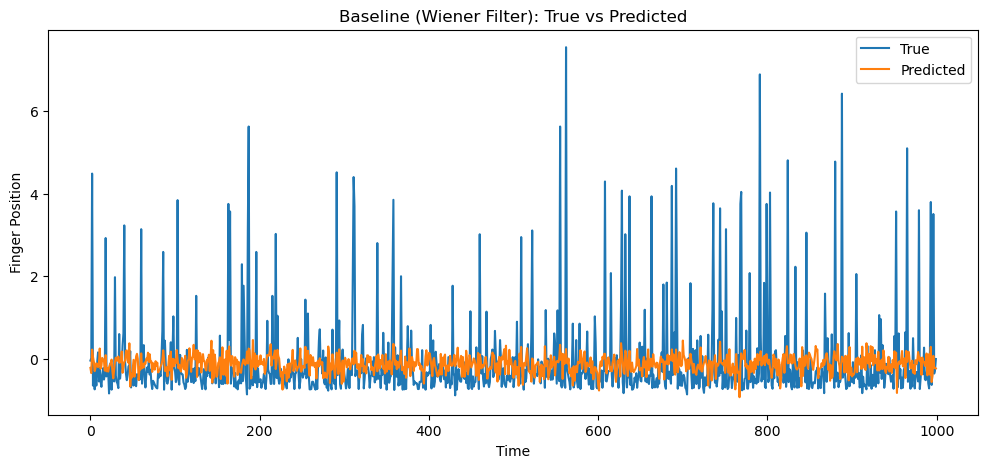

In [18]:
finger_idx = 0  # choose one finger

plt.figure(figsize=(12, 5))
plt.plot(y_val[:1000, finger_idx], label="True")
plt.plot(y_pred_baseline[:1000, finger_idx], label="Predicted")
plt.title("Baseline (Wiener Filter): True vs Predicted")
plt.xlabel("Time")
plt.ylabel("Finger Position")
plt.legend()
plt.show()

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(y_train.shape[1], activation='linear')
])

nn_model.compile(
    optimizer='adam',
    loss='mse'
)

nn_model.summary()

C:\Users\karta\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,853 (58.02 KB)

 Trainable params: 14,853 (58.02 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9082 - val_loss: 0.7580
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7406 - val_loss: 0.6169
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6497 - val_loss: 0.5399
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5967 - val_loss: 0.4908
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5636 - val_loss: 0.4635
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5424 - val_loss: 0.4348
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5248 - val_loss: 0.4219
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5094 - val_loss: 0.4106
Epoch 9/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5007 - val_loss: 0.3984
Epoch 10/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4914 - val_loss: 0.3874
Epoch 11/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4844 - val_loss: 0.3730
Epoch 12/30
1250/1250 ━━━━━━━━

In [22]:
y_pred_nn_original = nn_model.predict(X_val_scaled)

nn_r2 = r2_score(y_val, y_pred_nn_original, multioutput='uniform_average')

print("Neural Network R² score:", nn_r2)

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1s 493us/step
Neural Network R² score: 0.682314838672229


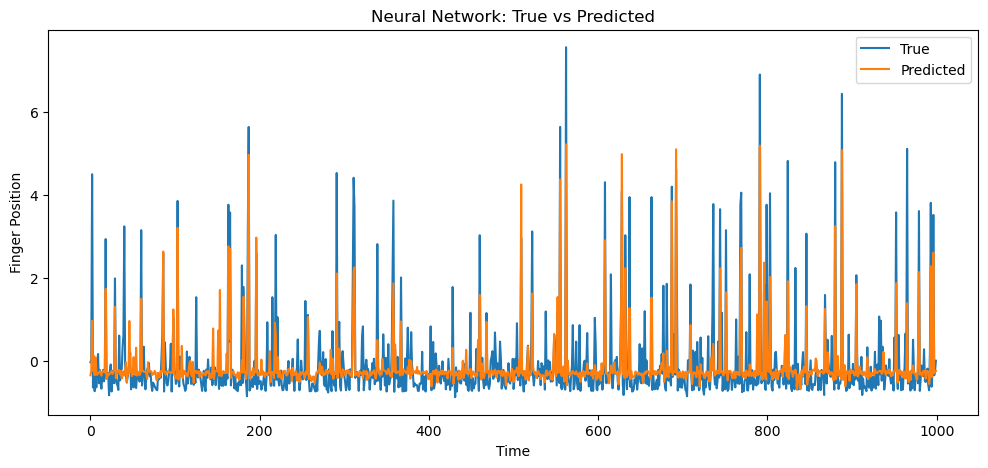

In [23]:
finger_idx = 0

plt.figure(figsize=(12, 5))
plt.plot(y_val[:1000, finger_idx], label="True")
plt.plot(y_pred_nn_original[:1000, finger_idx], label="Predicted")
plt.title("Neural Network: True vs Predicted")
plt.xlabel("Time")
plt.ylabel("Finger Position")
plt.legend()
plt.show()

In [24]:
def apply_channel_dropout(X, drop_fraction=0.3, random_state=42):
    np.random.seed(random_state)
    X_copy = X.copy()
    n_channels = X_copy.shape[1]
    n_drop = int(n_channels * drop_fraction)
    dropped_channels = np.random.choice(n_channels, n_drop, replace=False)
    X_copy[:, dropped_channels] = 0
    return X_copy, dropped_channels

In [25]:
X_val_drop30, dropped_channels = apply_channel_dropout(X_val_scaled, drop_fraction=0.3)

print("Dropped channel indices:", dropped_channels)
print("Number of dropped channels:", len(dropped_channels))

Dropped channel indices: [27 40 26 43 24 37 12 19  4 25  8  3  6 39]
Number of dropped channels: 14


In [26]:
y_pred_baseline_drop = baseline_model.predict(X_val_drop30)
baseline_drop_r2 = r2_score(y_val, y_pred_baseline_drop, multioutput='uniform_average')

print("Wiener Filter R² with 30% channel dropout:", baseline_drop_r2)

Wiener Filter R² with 30% channel dropout: 0.026617965183609326


In [27]:
y_pred_nn_drop = nn_model.predict(X_val_drop30)
nn_drop_r2 = r2_score(y_val, y_pred_nn_drop, multioutput='uniform_average')

print("Neural Network R² with 30% channel dropout:", nn_drop_r2)

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1s 501us/step
Neural Network R² with 30% channel dropout: 0.23781916275118914


In [28]:
results = pd.DataFrame({
    "Model": ["Wiener Filter", "Neural Network"],
    "Original R2": [baseline_r2, nn_r2],
    "30% Dropout R2": [baseline_drop_r2, nn_drop_r2]
})

print(results)

            Model  Original R2  30% Dropout R2
0   Wiener Filter     0.038428        0.026618
1  Neural Network     0.682315        0.237819


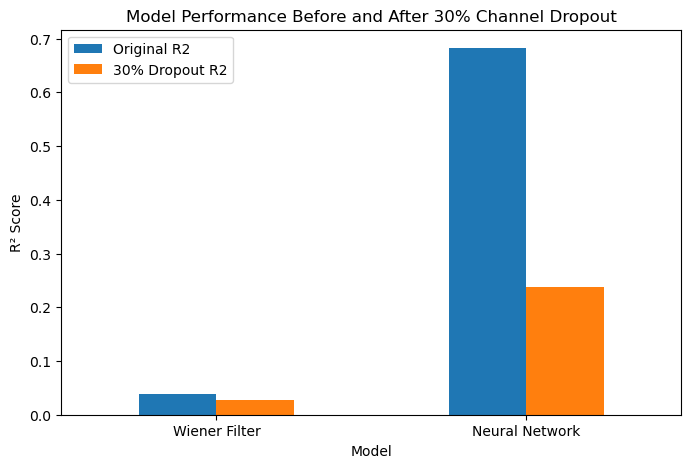

In [29]:
results.set_index("Model").plot(kind="bar", figsize=(8, 5))
plt.title("Model Performance Before and After 30% Channel Dropout")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

In [30]:
dropout_levels = [0.0, 0.1, 0.3, 0.5, 0.7]

In [31]:
dropout_results = []

for drop in dropout_levels:
    if drop == 0.0:
        X_test_drop = X_val_scaled
        dropped_channels = []
    else:
        X_test_drop, dropped_channels = apply_channel_dropout(
            X_val_scaled,
            drop_fraction=drop,
            random_state=42
        )

    y_pred_wiener = baseline_model.predict(X_test_drop)
    y_pred_nn_drop_loop = nn_model.predict(X_test_drop)

    wiener_r2 = r2_score(y_val, y_pred_wiener, multioutput='uniform_average')
    nn_r2_loop = r2_score(y_val, y_pred_nn_drop_loop, multioutput='uniform_average')

    dropout_results.append({
        "Dropout Level": f"{int(drop * 100)}%",
        "Wiener Filter R2": wiener_r2,
        "Neural Network R2": nn_r2_loop,
        "Dropped Channels": len(dropped_channels)
    })

dropout_results_df = pd.DataFrame(dropout_results)
dropout_results_df

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1s 500us/step
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1s 509us/step
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1s 499us/step
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1s 509us/step
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1s 498us/step


,Dropout Level,Wiener Filter R2,Neural Network R2,Dropped Channels
0,0%,0.038428,0.682315,0
1,10%,0.037010,0.513162,4
2,30%,0.026618,0.237819,14
3,50%,0.013478,0.028574,24
4,70%,-0.000793,-0.276051,33


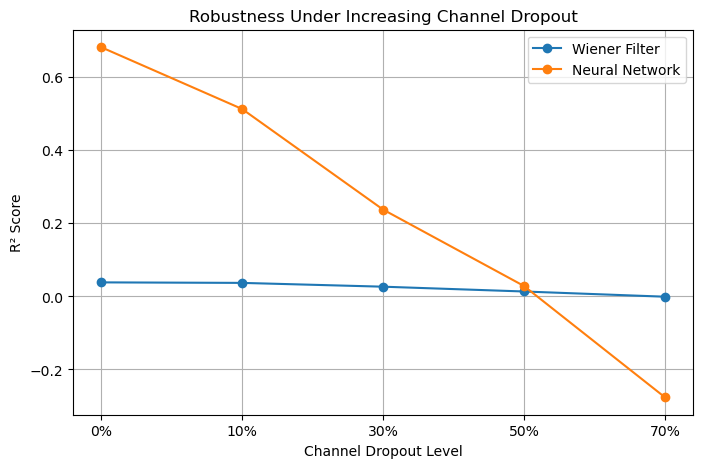

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(dropout_results_df["Dropout Level"], dropout_results_df["Wiener Filter R2"], marker='o', label="Wiener Filter")
plt.plot(dropout_results_df["Dropout Level"], dropout_results_df["Neural Network R2"], marker='o', label="Neural Network")
plt.title("Robustness Under Increasing Channel Dropout")
plt.xlabel("Channel Dropout Level")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
finger_r2_results = []

for i in range(y_val.shape[1]):
    finger_r2_results.append({
        "Finger": f"Finger {i+1}",
        "Wiener Filter R2": r2_score(y_val[:, i], y_pred_baseline[:, i]),
        "Neural Network R2": r2_score(y_val[:, i], y_pred_nn_original[:, i])
    })

finger_r2_df = pd.DataFrame(finger_r2_results)
finger_r2_df

,Finger,Wiener Filter R2,Neural Network R2
0,Finger 1,0.041398,0.681716
1,Finger 2,0.044692,0.655577
2,Finger 3,0.046091,0.751554
3,Finger 4,0.039958,0.644500
4,Finger 5,0.020001,0.678227


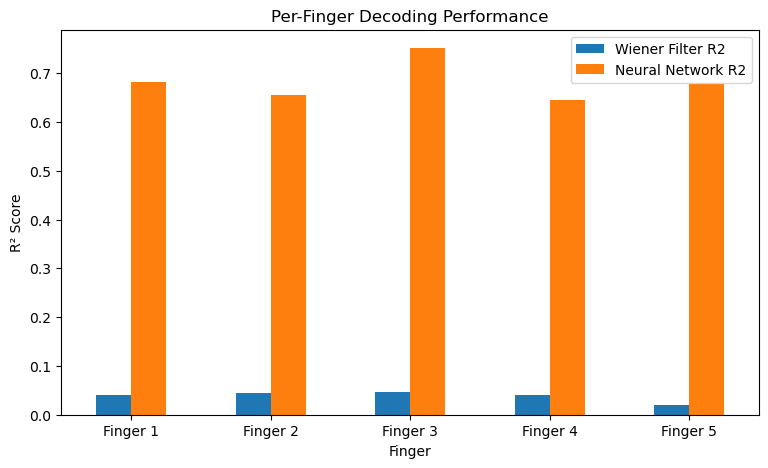

In [34]:
finger_r2_df.set_index("Finger").plot(kind="bar", figsize=(9, 5))
plt.title("Per-Finger Decoding Performance")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()